# MalthusJAX: Composer Basics

Welcome to the MalthusJAX Showcase! MalthusJAX is designed to be highly modular, blazingly fast (via JAX), and simple to use via the `Composer` API.

In this notebook, we'll demonstrate how to set up a simple Genetic Algorithm to solve a standard Black-Box Optimization Benchmark (BBOB) function.

In [1]:
import os
from pathlib import Path

# If running as a notebook in examples/showcase, change directory to the repository root
if Path(os.getcwd()).name == "showcase":
    os.chdir("../..")
print(f"Working Directory: {os.getcwd()}")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from malthusjax.composer.composer import Composer

# Set the backend to CPU/GPU based on your hardware availability
# For demonstration purposes, this will run blazingly fast even on CPU.

Working Directory: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX


## 1. Defining the Experiment

The `Composer` is the entry point for all experiments. You use `Composer.quick_run()` to easily orchestrate an evolutionary run by simply naming the components you want.

Let's optimize the **Rosenbrock** function in 5 dimensions. We'll use:
- A standard real-valued genome
- Tournament selection
- Uniform real crossover
- Gaussian mutation

In [4]:
composer = Composer()

print("Starting evolutionary run...")
result = composer.quick_run(
    backend="malthusjax",           # Use the native JAX engine
    genome="real",                  # Real-valued genomes
    fitness="bbob:fn_name=rosenbrock,num_dims=50",  # BBOB Rosenbrock function in 5D
    selection="tournament:tournament_size=3",      # Tournament selection
    crossover="uniform_real:crossover_rate=0.5",   # Uniform crossover
    mutation="gaussian:mutation_rate=0.1",# Gaussian mutation
    genome_length=50,                # Explicitly set genome length
    pop_size=100,                  # Population size
    generations=100,                # Number of generations
    maximize=False,                 # Rosenbrock is a minimization problem
    seed=42                         # For reproducibility
)

run = result.runs[0]
print(f"Run completed in {run.duration_seconds:.3f} seconds!")
print(f"Best Fitness Achieved: {run.metrics['best_fitness']:.4f}")

Starting evolutionary run...


seeds:   0%|          | 0/3 [00:00<?, ?it/s]

  - Seed 1/3 start (seed=1)
  - Seed 1/3 done status=success duration=2.28s


seeds:  33%|███▎      | 1/3 [00:02<00:04,  2.28s/it]

  - Seed 2/3 start (seed=2)
  - Seed 2/3 done status=success duration=0.88s


seeds:  67%|██████▋   | 2/3 [00:03<00:01,  1.46s/it]

  - Seed 3/3 start (seed=3)
  - Seed 3/3 done status=success duration=0.81s


seeds: 100%|██████████| 3/3 [00:03<00:00,  1.32s/it]

Run completed in 2.279 seconds!
Best Fitness Achieved: 596.4414


## 2. Analyzing the Results

The `Composer` returns an `ExperimentResult` which contains all the aggregated metrics and the complete history of the evolutionary run. Let's plot the convergence!

Plot saved to results/showcase/01_convergence.png


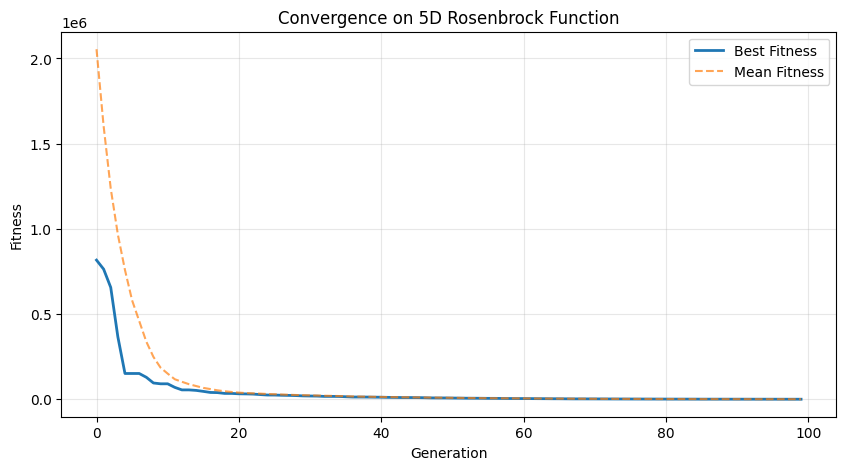

In [5]:
generations = jnp.arange(len(run.history))
best_fitness = jnp.array([h["best_fitness"] for h in run.history])
mean_fitness = jnp.array([h["mean_fitness"] for h in run.history])

plt.figure(figsize=(10, 5))
plt.plot(generations, best_fitness, label="Best Fitness", linewidth=2)
plt.plot(generations, mean_fitness, label="Mean Fitness", linestyle="--", alpha=0.7)
plt.title("Convergence on 5D Rosenbrock Function")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True, alpha=0.3)
import os
os.makedirs("results/showcase", exist_ok=True)
plt.savefig("results/showcase/01_convergence.png")
print("Plot saved to results/showcase/01_convergence.png")
# plt.show() # Uncomment to view interactively

And that's it! With just a single function call to `Composer.quick_run()`, you've assembled a full evolutionary pipeline compiled in JAX. 

Next up, check out **02_universal_adapters.py** to see how easily you can swap the backend out for powerful external libraries like EvoSAX or QDAX without changing your boilerplate!